In [1]:
#packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import (load_data, confusion_table)
from ISLP.models import (ModelSpec as MS, summarize, contrast)
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import RocCurveDisplay, roc_auc_score, log_loss

roc_curve_est = RocCurveDisplay.from_estimator 
roc_curve_pred = RocCurveDisplay.from_predictions 

### This project will use the [Sleep, Health, and Lifestyle dataset](https://www.kaggle.com/datasets/ayeshaimran1619/sleep-and-lifestyle-study) from Kaggle.

In [2]:
sleep = pd.read_csv('data/Sleep_health_and_lifestyle_dataset.csv')
sleep.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


### Data Preprocessing

#### - Split blood pressure into systolic (artery pressure during contractions) and diastolic (pressure when heart relaxes between beats)
#### - Use one-hot encoding for categorical variables

In [3]:
sleep[['Systolic BP', 'Diastolic BP']] = sleep['Blood Pressure'].str.split('/', expand = True).astype(int)

sleep['BMI Category'] = sleep['BMI Category'].replace('Normal Weight', 'Normal')

sleep['Has Disorder'] = sleep['Sleep Disorder'].notna().astype(int)

# save this variable to be used in later models before dropping
y_multi = sleep['Sleep Disorder'].fillna('None')

sleep = sleep.drop(['Blood Pressure', 'Sleep Disorder', 'Person ID'], axis=1)

categorical_columns = ['Gender', 'Occupation', 'BMI Category']
sleep = pd.get_dummies(sleep, columns = categorical_columns, drop_first = True, dtype = int)

sleep

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic BP,Diastolic BP,Has Disorder,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Obese,BMI Category_Overweight
0,27,6.1,6,42,6,77,4200,126,83,0,...,0,0,0,0,0,0,1,0,0,1
1,28,6.2,6,60,8,75,10000,125,80,0,...,0,0,0,0,0,0,0,0,0,0
2,28,6.2,6,60,8,75,10000,125,80,0,...,0,0,0,0,0,0,0,0,0,0
3,28,5.9,4,30,8,85,3000,140,90,1,...,0,0,0,1,0,0,0,0,1,0
4,28,5.9,4,30,8,85,3000,140,90,1,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,59,8.1,9,75,3,68,7000,140,95,1,...,0,0,1,0,0,0,0,0,0,1
370,59,8.0,9,75,3,68,7000,140,95,1,...,0,0,1,0,0,0,0,0,0,1
371,59,8.1,9,75,3,68,7000,140,95,1,...,0,0,1,0,0,0,0,0,0,1
372,59,8.1,9,75,3,68,7000,140,95,1,...,0,0,1,0,0,0,0,0,0,1


### To begin, we will use Logistic Regression to determine the presence of a sleep disorder rather than a specific diagnosis.

In [4]:
# isolate binary sleep disorders column (target variable)
X = sleep.drop('Has Disorder', axis=1)
y = sleep['Has Disorder']

x_train, x_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=314159,
                                                    test_size=0.33,
                                                    shuffle=True)

# add dummy variables 
x_train['intercept'] = np.ones(x_train.shape[0])
x_test['intercept'] = np.ones(x_test.shape[0])

### Scale features using min-max regularization

In [5]:
needs_scaled = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']

for col in needs_scaled:
    col_min = x_train[col].min()
    col_max = x_train[col].max()

    x_train[col] = (x_train[col] - col_min) / (col_max - col_min)
    
    x_test[col] = (x_test[col] - col_min) / (col_max - col_min)

In [6]:
initial_glm = sm.GLM(y_train,
             x_train,
             family=sm.families.Binomial())

# fit model
initial_results = initial_glm.fit()

# analyze model
summarize(initial_results)

,coef,std err,z,P>|z|
Age,3.828600e+00,6.592000e+00,0.581,0.561
Sleep Duration,4.850000e-02,5.357000e+00,0.009,0.993
Quality of Sleep,-1.326800e+01,1.022800e+01,-1.297,0.195
Physical Activity Level,-3.107100e+00,2.765000e+00,-1.124,0.261
Stress Level,-4.905300e+00,6.147000e+00,-0.798,0.425
Heart Rate,-1.540500e+00,9.693000e+00,-0.159,0.874
Daily Steps,-2.414000e-01,4.537000e+00,-0.053,0.958
Systolic BP,-2.430800e+00,1.174700e+01,-0.207,0.836
Diastolic BP,2.012820e+01,1.391600e+01,1.446,0.148
Gender_Male,1.365000e+00,2.637000e+00,0.518,0.605


### Since the above model will likely be overfit, we can try a subset of features 

In [7]:
# Print correlations between each feature and "Has Disorder"
sleep.corr()['Has Disorder'].sort_values()

Sleep Duration                    -0.338622
Quality of Sleep                  -0.310984
Occupation_Doctor                 -0.310362
Occupation_Engineer               -0.291633
Gender_Male                       -0.285824
Occupation_Lawyer                 -0.237076
Occupation_Manager                -0.043560
Occupation_Software Engineer      -0.034707
Daily Steps                       -0.026575
Occupation_Scientist               0.018059
Physical Activity Level            0.069787
Occupation_Sales Representative    0.087156
Stress Level                       0.181685
BMI Category_Obese                 0.197018
Occupation_Teacher                 0.253291
Occupation_Salesperson             0.324787
Heart Rate                         0.330254
Age                                0.432007
Occupation_Nurse                   0.462127
Systolic BP                        0.692480
Diastolic BP                       0.705025
BMI Category_Overweight            0.751018
Has Disorder                    

### Now we can train a logistic regression model using features with the strongest correlations.

In [8]:
variables_to_use = ['BMI Category_Overweight', 'Systolic BP', 'Occupation_Nurse', 'Age', 'Heart Rate', 'Sleep Duration', 'Quality of Sleep']

glm = sm.GLM(y_train, x_train[variables_to_use], family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
BMI Category_Overweight,1.0251,0.792,1.294,0.196
Systolic BP,7.2324,1.877,3.853,0.000
Occupation_Nurse,-0.4083,0.770,-0.531,0.596
Age,2.9209,1.883,1.551,0.121
Heart Rate,-1.9399,1.170,-1.657,0.097
Sleep Duration,2.6615,1.880,1.416,0.157
Quality of Sleep,-10.1262,2.246,-4.508,0.000


### Once the model is trained, we can calculate the predicted probablilities and generate a confusion table for the training set

In [9]:
def predict(X, model):
    # the built-in get_prediction tool returns an array, so we need to convert to a dataframe
    predictions_df = pd.DataFrame(model.get_prediction(X).predicted, columns=['y_hat'], index=X.index)
    return predictions_df['y_hat']

probs_train=predict(x_train[variables_to_use],results)
probs_test=predict(x_test[variables_to_use],results)

predictions_train = np.array([True]*len(y_train))
predictions_train[probs_train<0.5] = False

predictions_test = np.array([True]*len(y_test))
predictions_test[probs_test<0.5] = False

train_table = confusion_table(predictions_train, y_train)
train_table


Truth,0,1
Predicted,,
0,139,12
1,6,93


### And the test set

In [10]:
test_table = confusion_table(predictions_test, y_test)
test_table

Truth,0,1
Predicted,,
0,69,3
1,5,47


In [11]:
misclassification_rate = (test_table.loc[1, 0] + test_table.loc[0, 1]) / test_table.values.sum()
print("misclassification rate =", misclassification_rate)

false_positive_rate = test_table.loc[1, 0] / test_table[0].sum()
print("fpr =",false_positive_rate)

false_negative_rate = test_table.loc[0, 1] / test_table[1].sum()
print("fnr =",false_negative_rate)

misclassification rate = 0.06451612903225806
fpr = 0.06756756756756757
fnr = 0.06


### Using logistic regression, we can determine whether an individual has a sleep disorder with a total misclassification rate of 6.4%, a false positive rate of 6.8%, and a false negative rate of 6%.

### Now we can see how the model performs using an ROC curve

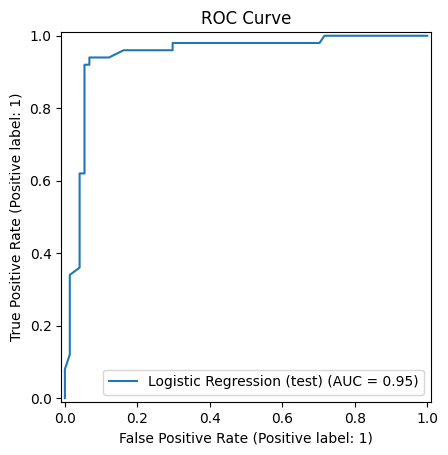

AUC = 0.9451351351351351


In [12]:
roc_curve_pred(y_test, probs_test, name='Logistic Regression (test)')
plt.title('ROC Curve')
plt.show()
print("AUC =", roc_auc_score(y_test, probs_test))

### An area under the curve of 95% indicates that the model is very accurate, since an AUC of 1.0 is perfect and 0.5 means the model is no better than random guessing.

### Next, we will use a random forest to predict which disorder, if any, an individual has

In [13]:
# Since we dropped the column to perform a binary classification with logistic regression, we saved it as y_multi to be used here
y_multi

0             None
1             None
2             None
3      Sleep Apnea
4      Sleep Apnea
          ...     
369    Sleep Apnea
370    Sleep Apnea
371    Sleep Apnea
372    Sleep Apnea
373    Sleep Apnea
Name: Sleep Disorder, Length: 374, dtype: object

### Align y_multi with the existing train/test split and train the random forest classifier using all features

In [ ]:
y_train_m = y_multi.loc[x_train.index]
y_test_m = y_multi.loc[x_test.index]

rf_basic = RFC(n_estimators=100,
         max_features=5,
         criterion='log_loss',
         max_depth=10,
         bootstrap=True,
         oob_score=True,
         random_state=314159)

rf_basic.fit(x_train, y_train_m)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'log_loss'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

### Compute the log loss and out-of-bag loss for the basic model

In [ ]:
train_ll = log_loss(y_train_m, rf_basic.predict_proba(x_train))
test_ll  = log_loss(y_test_m,  rf_basic.predict_proba(x_test))

oob_ll = log_loss(
    y_train_m,
    rf_basic.oob_decision_function_[~np.isnan(rf_basic.oob_decision_function_).any(axis=1)]
)

print('train log loss:', train_ll)
print('oob log loss:  ', oob_ll)
print('test log loss: ', test_ll)

train log loss: 0.1430721170725924
oob log loss:   1.6365878790268558
test log loss:  2.50853043230423


### We can improve the basic model by tuning the RFC parameters

In [47]:
rf = RFC(n_estimators=1000,
         max_features=10,
         criterion='log_loss',
         max_depth=10,
         min_samples_leaf=13,
         bootstrap=True,
         oob_score=True,
         random_state=314159)

rf.fit(x_train, y_train_m)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'log_loss'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",13
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",10
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Calculate log losses

In [48]:
train_ll = log_loss(y_train_m, rf.predict_proba(x_train))
test_ll  = log_loss(y_test_m,  rf.predict_proba(x_test))

oob_ll = log_loss(
    y_train_m,
    rf.oob_decision_function_[~np.isnan(rf.oob_decision_function_).any(axis=1)]
)

print('train log loss:', train_ll)
print('oob log loss:  ', oob_ll)
print('test log loss: ', test_ll)

train log loss: 0.309543829612291
oob log loss:   0.41324905141288093
test log loss:  0.44676485698246365


### Generate and plot the feature importance list

<BarContainer object of 22 artists>

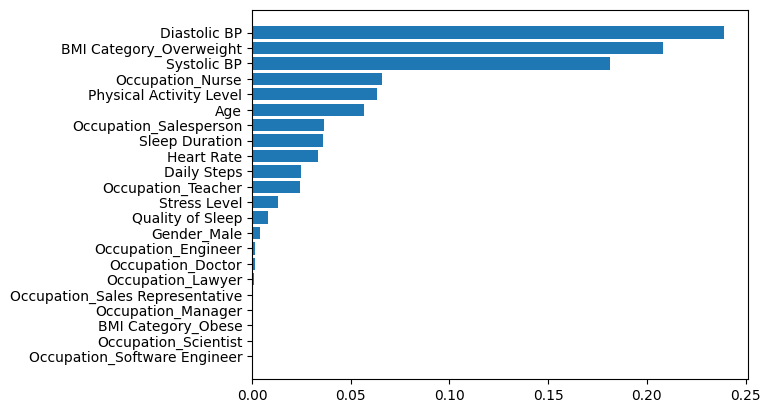

In [ ]:
feature_imp = pd.DataFrame(
    {'importance':rf.feature_importances_},
    index=x_train.columns)

# drop intercept since it is only used in logistic regression
feature_imp = feature_imp.drop('intercept')

feature_imp_sorted = feature_imp.sort_values(by='importance')

plt.barh(feature_imp_sorted.index, feature_imp_sorted['importance'])